![Evidence 3](https://i.imgur.com/mu6ZuGT.jpg)

# Instituto Tecnológico y de Estudios Superiores de Monterrey
## Maestría en Inteligencia Artificial Aplicada
### Proyecto Integrador (Gpo 10)

### **Proyecto: Diseño Acelerado de Fármacos Agonistas de la Proteína PD-L1**

### Avance 5: Modelo final

#### **Docentes:**
- Dra. Grettel Barceló Alonso - Profesor Titular
- Dra. Eduviges Ludivina Facundo Flores  – Profesor Tutor

### **Asesores**
- Dr. Juan Arturo Nolazco Flores
- Dr. Carlos Alberto Brizuela Rodríguez

### **Equipo 2:**

* Maritza Liceth Guerrero Millán: A01795976
* Juan Luis García Chávez: A01795943
* Miguel Ángel Loya Tarango: A01796407

## Introducción

En etapas previas del proyecto se llevó a cabo un análisis exploratorio de datos (EDA) y un proceso de ingeniería de características con el objetivo de comprender la distribución de las métricas estructurales y de interacción proteína-proteína generadas por los modelos de predicción estructural. Este análisis permitió identificar patrones relevantes en variables como las métricas de plegamiento individual y de interacción entre cadenas, así como evaluar el comportamiento de distintas representaciones de las secuencias peptídicas.

Posteriormente, se construyeron modelos baseline utilizando características derivadas de la composición aminoacídica y otras propiedades numéricas simples. Estos modelos iniciales permitieron validar que el problema contiene señal predictiva suficiente y establecer un punto de comparación para enfoques más avanzados. Los resultados obtenidos indicaron que era posible capturar relaciones no triviales entre la secuencia peptídica y las métricas estructurales predichas, lo que justificó explorar representaciones más ricas de las secuencias.

En esta etapa final del proyecto, las secuencias peptídicas se transformaron en representaciones vectoriales mediante embeddings derivados de modelos de lenguaje de proteínas. Estos embeddings permiten capturar información contextual y estructural implícita en la secuencia, proporcionando una representación numérica de alta dimensionalidad que refleja propiedades bioquímicas, evolutivas y estructurales aprendidas por modelos entrenados sobre grandes corpus de proteínas.

Una vez generadas estas representaciones, se evaluaron diversos algoritmos de aprendizaje supervisado para predecir las métricas estructurales de interés. Tras comparar el desempeño de distintos modelos, XGBoost fue seleccionado como el modelo final debido a que consistentemente obtuvo los mejores resultados en términos de métricas de regresión y estabilidad durante la validación cruzada. Este algoritmo, basado en gradient boosting sobre árboles de decisión, es particularmente adecuado para manejar relaciones no lineales y estructuras complejas en datos de alta dimensionalidad como los embeddings de proteínas.

El objetivo de este notebook es, por tanto, entrenar y evaluar el modelo final basado en XGBoost, utilizando los embeddings de las secuencias como variables predictoras para estimar métricas estructurales generadas por los modelos de predicción de estructuras proteicas. Este enfoque combina el poder representacional de los modelos de lenguaje de proteínas con la capacidad de generalización de métodos de ensemble basados en árboles.

En síntesis, este paso integra las distintas etapas del proyecto —generación de secuencias, obtención de representaciones profundas y modelado supervisado— para construir un modelo predictivo robusto capaz de anticipar el comportamiento estructural de los péptidos candidatos y apoyar la priorización de aquellos con mayor potencial de interacción con PD-L1.

## Instalación

!pip install fair-esm

In [2]:
!pip install numpy pandas scikit-learn xgboost matplotlib seaborn torch

Defaulting to user installation because normal site-packages is not writeable


## Imports

In [ ]:
# =========================
# Core libraries
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Machine Learning (sklearn)
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# =========================
# Gradient Boosting
# =========================
import xgboost as xgb

# =========================
# Deep Learning
# =========================
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# Protein Language Models
# =========================
import esm

# =========================
# Utilities
# =========================
from tqdm import tqdm

## Generación de embeddings de secuencias proteicas con ESM-2

Este código implementa un pipeline para transformar secuencias proteicas en **representaciones numéricas (embeddings)** utilizando un modelo de lenguaje de proteínas preentrenado. El objetivo es obtener vectores que capturen información estructural, bioquímica y evolutiva de las secuencias, para posteriormente utilizarlos como variables de entrada en modelos de aprendizaje automático.

En primer lugar, se define la configuración del proceso, incluyendo el modelo a utilizar (**ESM-2 con 33 capas y aproximadamente 650 millones de parámetros**), el tamaño de lote para el procesamiento de secuencias y el dispositivo de cómputo. El código detecta automáticamente si existe una GPU disponible y, en caso afirmativo, ejecuta el modelo en ella para acelerar el cálculo.

Posteriormente se carga el modelo preentrenado junto con su **alfabeto de aminoácidos**, que contiene el vocabulario utilizado por el modelo. A través del `batch_converter` se transforman las secuencias de texto en tensores de tokens que el modelo puede procesar. El modelo se coloca en modo evaluación (`eval`) para desactivar componentes utilizados durante el entrenamiento, como el *dropout*, y garantizar resultados deterministas.

El dataset se carga desde un archivo CSV que contiene las secuencias proteicas. Algunas secuencias pueden contener múltiples cadenas separadas por el carácter `/`, lo cual es común cuando se representan complejos proteína-proteína. En estos casos, cada cadena se procesa de manera independiente.

La función `generate_embeddings` constituye el núcleo del proceso. Para cada secuencia:

1. Se separan las cadenas individuales.
2. Cada cadena se convierte a tokens y se introduce en el modelo ESM.
3. Se extraen las representaciones internas de la **última capa del modelo (layer 33)**.
4. Se eliminan los tokens especiales y se obtiene el embedding correspondiente a cada aminoácido.
5. Se aplica **mean pooling**, promediando los embeddings de todos los aminoácidos para obtener un único vector que represente la cadena completa.
6. Si la secuencia contiene varias cadenas, los vectores resultantes se **concatenan** para formar la representación final.

Para mejorar la eficiencia y evitar problemas de memoria, las secuencias se procesan por lotes utilizando un `BATCH_SIZE` definido previamente. Los embeddings generados para cada lote se almacenan y posteriormente se combinan en una sola matriz.

Finalmente, los embeddings se agregan como una nueva columna en el dataframe original y el dataset enriquecido se guarda en formato **pickle** (`dataset_with_embeddings.pkl`). Este formato permite almacenar directamente estructuras de datos complejas como vectores NumPy dentro del dataframe, facilitando su carga posterior para entrenar modelos de machine learning.

En resumen, este proceso convierte secuencias proteicas —originalmente representadas como cadenas de aminoácidos— en **vectores numéricos informativos** que pueden ser utilizados como entrada para modelos predictivos posteriores, como el modelo final basado en **XGBoost** utilizado en este proyecto.

In [ ]:
# ===============================
# CONFIG
# ===============================

MODEL_NAME = "esm2_t33_650M_UR50D"
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

# ===============================
# LOAD MODEL
# ===============================

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()

model.eval()
model = model.to(DEVICE)

LAYER = 33  # last layer

# ===============================
# LOAD DATA
# ===============================

# archivo con columna 'sequence'
df = pd.read_csv("../dataset.csv")

# ejemplo de secuencia:
# GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTNEIFYCTFRRLDPEENHTAELVIPELP/EVTLTGSLEEPLLP


# ===============================
# FUNCTION: GENERATE EMBEDDINGS
# ===============================

def generate_embeddings(sequences):

    all_embeddings = []

    for seq in sequences:

        # separar cadenas
        chains = seq.split("/")

        chain_embeddings = []

        for chain in chains:

            data = [("protein", chain)]

            labels, strs, tokens = batch_converter(data)
            tokens = tokens.to(DEVICE)

            with torch.no_grad():
                outputs = model(tokens, repr_layers=[LAYER])

            reps = outputs["representations"][LAYER]

            seq_len = len(chain)

            # quitar BOS token
            emb = reps[0, 1:seq_len+1]

            # mean pooling
            emb = emb.mean(0)

            chain_embeddings.append(emb.cpu().numpy())

        # concatenar cadenas
        final_embedding = np.concatenate(chain_embeddings)

        all_embeddings.append(final_embedding)

    return np.array(all_embeddings)


# ===============================
# GENERATE
# ===============================

embeddings = []

for i in tqdm(range(0, len(df), BATCH_SIZE)):

    batch_seqs = df["seq"].iloc[i:i+BATCH_SIZE].tolist()

    batch_emb = generate_embeddings(batch_seqs)

    embeddings.append(batch_emb)

embeddings = np.vstack(embeddings)

# ===============================
# ADD EMBEDDINGS TO DATASET
# ===============================

df["embedding"] = list(embeddings)

print("Embeddings shape:", embeddings.shape)
print("Dataset shape:", df.shape)

# ===============================
# SAVE DATASET
# ===============================

df.to_pickle("dataset_with_embeddings.pkl")

print("Dataset con embeddings guardado")

## Cargar dataset

In [ ]:
df = pd.read_pickle("utils/dataset_with_embeddings.pkl")

print(df.shape)

df.head()

(28800, 9)


,mpnn,plddt,ptm,i_ptm,pae,i_pae,rmsd,seq,embedding
0,1.610,0.759,0.716,0.687,6.965,7.368,5.898,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,"[0.04168843, -0.06093624, -0.024661286, 0.0410..."
1,1.593,0.589,0.664,0.493,10.559,11.163,1.549,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,"[0.04168843, -0.06093624, -0.024661286, 0.0410..."
2,1.599,0.787,0.728,0.721,6.648,7.012,5.711,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,"[0.04168843, -0.06093624, -0.024661286, 0.0410..."
3,1.578,0.759,0.716,0.687,6.965,7.368,5.898,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,"[0.04168843, -0.06093624, -0.024661286, 0.0410..."
4,1.656,0.762,0.706,0.696,7.129,7.536,4.984,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,"[0.04168843, -0.06093624, -0.024661286, 0.0410..."


## Cargar embeddings
Cargamos los embeddings y le agregamos la columna MPNN, que representa el score asignado por el modelo de diseño de secuencias generado por ProteinMPNN

In [54]:
embeddings = np.vstack(df["embedding"].values)

print("Embedding shape:", embeddings.shape)

mpnn = df["mpnn"].to_numpy().reshape(-1, 1)

embeddings = np.hstack((embeddings, mpnn))

print("New shape:", embeddings.shape)

Embedding shape: (28800, 2560)
New shape: (28800, 2561)


## Targets
Definimos las variables PTM y iPTM como targets

In [56]:
y = df[["ptm", "i_ptm"]].values

print(y.shape)

(28800, 2)


## Preparar features

In [59]:
X = embeddings

print(X.shape)

(28800, 2561)


In [60]:
X = pd.DataFrame(embeddings)
X.head()

,0,1,2,3,4,5,6,7,8,9,...,2551,2552,2553,2554,2555,2556,2557,2558,2559,2560
0,0.041688,-0.060936,-0.024661,0.041046,-0.084833,-0.040022,0.07502,0.056539,0.004585,0.136051,...,-0.030976,-0.132497,0.104120,-0.045822,0.095596,-0.024521,-0.026604,-0.038315,0.041367,1.610
1,0.041688,-0.060936,-0.024661,0.041046,-0.084833,-0.040022,0.07502,0.056539,0.004585,0.136051,...,0.001975,-0.139056,0.097600,-0.048785,0.071939,0.000503,-0.030503,0.006466,-0.039909,1.593
2,0.041688,-0.060936,-0.024661,0.041046,-0.084833,-0.040022,0.07502,0.056539,0.004585,0.136051,...,0.044597,-0.171265,0.120668,-0.073223,0.079329,-0.026358,0.042512,-0.083082,0.015142,1.599
3,0.041688,-0.060936,-0.024661,0.041046,-0.084833,-0.040022,0.07502,0.056539,0.004585,0.136051,...,-0.030976,-0.132497,0.104120,-0.045822,0.095596,-0.024521,-0.026604,-0.038315,0.041367,1.578
4,0.041688,-0.060936,-0.024661,0.041046,-0.084833,-0.040022,0.07502,0.056539,0.004585,0.136051,...,0.030161,-0.167302,0.108558,-0.050548,0.085926,-0.018866,0.054956,-0.072274,0.010273,1.656


## Train/Test split

In [61]:
print("Dataset shape:", df.shape)

print("Embeddings shape:", embeddings.shape)

print("Targets shape:", y.shape)

Dataset shape: (28800, 9)
Embeddings shape: (28800, 2561)
Targets shape: (28800, 2)


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Escalado

In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Función de evaluación

In [66]:
def evaluate_model(name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print("MSE:", mse)
    print("MAE:", mae)
    print("R2:", r2)

    return mse, mae, r2

## Entrenamiento del modelo XGBoost

En esta etapa se entrena el modelo final utilizando **XGBoost**, un algoritmo de *gradient boosting* basado en árboles de decisión que es especialmente eficaz para capturar relaciones no lineales en datos de alta dimensionalidad.

Primero se inicializa el modelo `XGBRegressor` definiendo algunos hiperparámetros clave que controlan la complejidad del modelo y su proceso de aprendizaje:

- **n_estimators = 400**: número de árboles que compondrán el ensemble. Un mayor número de árboles permite capturar patrones más complejos, aunque incrementa el tiempo de entrenamiento.
- **max_depth = 8**: profundidad máxima de cada árbol. Este parámetro controla la complejidad de los árboles y ayuda a evitar el sobreajuste.
- **learning_rate = 0.05**: tasa de aprendizaje que determina cuánto contribuye cada árbol nuevo al modelo final. Valores más pequeños suelen mejorar la generalización, aunque requieren más árboles.
- **subsample = 0.8**: fracción de muestras utilizada para entrenar cada árbol. Introduce aleatoriedad para reducir el sobreajuste.
- **colsample_bytree = 0.8**: fracción de características utilizadas en cada árbol, lo cual también ayuda a mejorar la capacidad de generalización.

Posteriormente, el modelo se entrena utilizando los datos de entrenamiento transformados mediante **PCA** (`X_train_pca`) y las variables objetivo correspondientes (`y_train`). El uso de PCA permite reducir la dimensionalidad de los embeddings generados previamente, manteniendo la mayor parte de la varianza informativa y facilitando el aprendizaje del modelo.

Una vez entrenado, el modelo se utiliza para generar predicciones sobre el conjunto de prueba (`X_test_pca`). Estas predicciones se comparan con los valores reales (`y_test`) utilizando la función `evaluate_model`, la cual calcula métricas de desempeño como **MSE, MAE y R²**, permitiendo evaluar la capacidad del modelo para predecir correctamente las métricas estructurales de interés.

Este paso completa el entrenamiento del modelo final del pipeline, que combina **embeddings de secuencias proteicas, reducción de dimensionalidad mediante PCA y un modelo de gradient boosting (XGBoost)** para estimar propiedades estructurales derivadas de modelos de predicción de proteínas.

In [87]:
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train_pca, y_train)

pred_xgb = xgb_model.predict(X_test_pca)

evaluate_model("XGBoost", y_test, pred_xgb)

XGBoost
MSE: 0.0014741617349583501
MAE: 0.01405138382311493
R2: 0.9266443976861047


(0.0014741617349583501, 0.01405138382311493, 0.9266443976861047)

## Scatter plots (real vs predicho)

Visualizamos las diferencias entre valores reales vs valores predichos por nuestro modelo

In [97]:
def plot_predictions(true, pred, title):

    plt.figure(figsize=(5,5))

    plt.scatter(true, pred, alpha=0.4)

    plt.xlabel("True")
    plt.ylabel("Predicted")

    plt.title(title)

    plt.plot([0,1],[0,1])

    plt.show()

## pTM

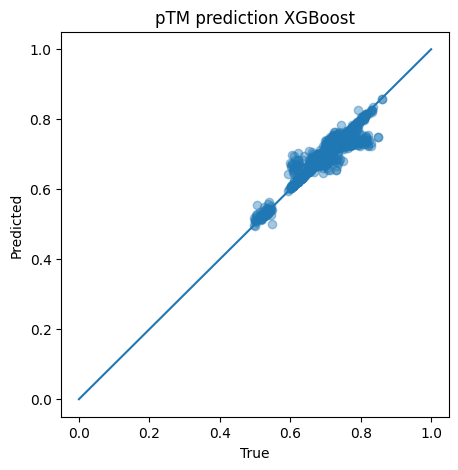

In [100]:
plot_predictions(y_test[:,0], pred_xgb[:,0], "pTM prediction XGBoost")

## ipTM

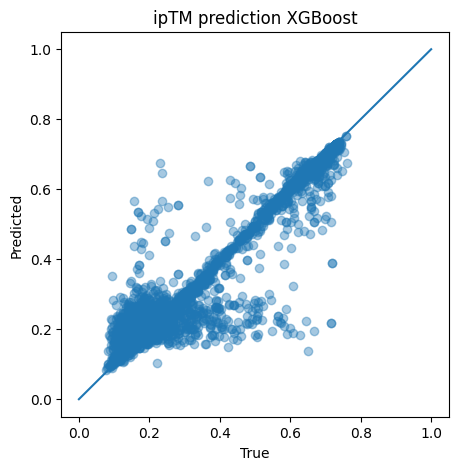

In [104]:
plot_predictions(y_test[:,1], pred_xgb[:,1], "ipTM prediction XGBoost")

## Guardar modelo
Guardamos el modelo para poder integrarlo en el pipeline final y usarlo en modo inferencia 

In [ ]:
import joblib
joblib.dump(xgb_model,"xgb_model.pkl")

## Conclusión del modelo

Los resultados obtenidos indican que el modelo basado en **XGBoost** logra un desempeño predictivo sólido al estimar la métrica objetivo a partir de los embeddings derivados de las secuencias proteicas. En particular, el modelo alcanza un **R² de 0.93**, lo que implica que aproximadamente el **93% de la variabilidad observada en los datos puede ser explicada por el modelo**. Este nivel de ajuste sugiere que las representaciones generadas a partir de las secuencias contienen información altamente relevante para predecir la propiedad estructural analizada.

Adicionalmente, los valores de **MSE (0.00147)** y **MAE (0.014)** indican que el error promedio de predicción es relativamente bajo, lo cual refuerza la capacidad del modelo para aproximar con precisión los valores reales. En términos prácticos, esto significa que el modelo puede estimar de manera confiable el comportamiento estructural esperado de nuevas secuencias sin necesidad de ejecutar directamente procesos computacionales más costosos como simulaciones estructurales completas.

Estos resultados confirman la hipótesis central del pipeline: **los embeddings generados por modelos de lenguaje de proteínas capturan suficiente información estructural y funcional para permitir la predicción de métricas relevantes mediante modelos supervisados relativamente simples**. La combinación de representaciones profundas de secuencias con un algoritmo robusto de *gradient boosting* como XGBoost demuestra ser una estrategia efectiva para modelar relaciones complejas entre secuencia y propiedades estructurales.

En conjunto, este modelo constituye una herramienta útil para **priorizar candidatos de secuencias peptídicas**, permitiendo identificar aquellas con mayor probabilidad de presentar propiedades estructurales favorables antes de someterlas a evaluaciones más costosas. Como trabajo futuro, el enfoque podría ampliarse incorporando datasets más grandes, explorando modelos multiobjetivo para predecir múltiples métricas simultáneamente, o utilizando representaciones aún más especializadas derivadas de modelos de lenguaje de proteínas de última generación.